### Section 1: Import Libraries

In [28]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Section 2: Load Dataset

In [29]:
df = pd.read_csv("../data/raw/churn.csv")

# Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

In [30]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


### Section 3 — Dataset Overview

In [31]:
print(f"Shape: {df.shape}")

df.info()

df.describe()

Shape: (3150, 14)
<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call Failure             3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription Length      3150 non-null   int64  
 3   Charge Amount            3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), in

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


### Section 4 — Missing Values

In [32]:
missing = df.isnull().sum()

missing

Call Failure               0
Complains                  0
Subscription Length        0
Charge Amount              0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

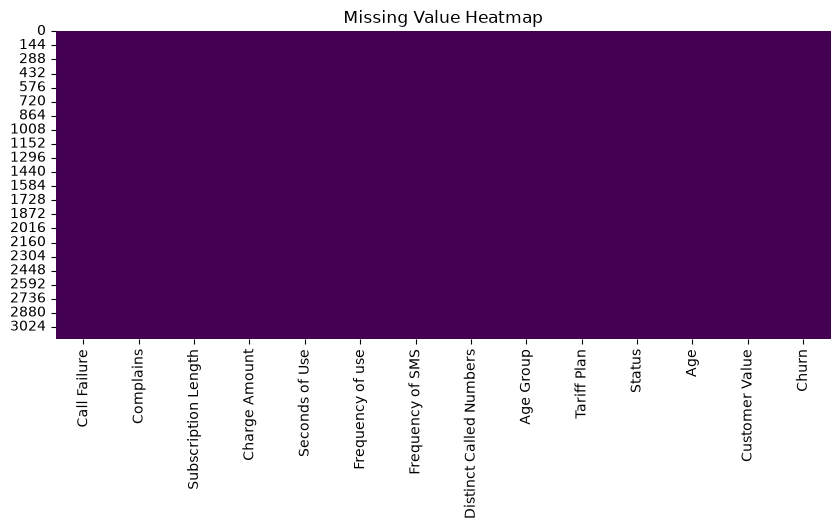

In [33]:
plt.figure(figsize=(10,4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

### Observation

No missing values were found in the dataset.

Therefore, no imputation techniques were required before further preprocessing.

### Section 5 — Duplicate Analysis

In [34]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 300


In [35]:
df = df.drop_duplicates()

print(df.shape)

(2850, 14)


### Observation

The dataset contained **300 duplicate records**, which were removed to prevent redundant information from influencing model training.

The cleaned dataset now contains **2850 unique customer records**.

### Section 6 — Data Type Validation

In [36]:
df.dtypes

Call Failure                 int64
Complains                    int64
Subscription Length          int64
Charge Amount                int64
Seconds of Use               int64
Frequency of use             int64
Frequency of SMS             int64
Distinct Called Numbers      int64
Age Group                    int64
Tariff Plan                  int64
Status                       int64
Age                          int64
Customer Value             float64
Churn                        int64
dtype: object

In [37]:
dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Unique Values": df.nunique().values
})

dtype_df

,Column,Data Type,Unique Values
0,Call Failure,int64,37
1,Complains,int64,2
2,Subscription Length,int64,45
3,Charge Amount,int64,11
4,Seconds of Use,int64,1756
5,Frequency of use,int64,242
6,Frequency of SMS,int64,405
7,Distinct Called Numbers,int64,92
8,Age Group,int64,5
9,Tariff Plan,int64,2


## Observation

All variables are already stored using appropriate numerical data types.

No categorical encoding is required because the dataset is already numerically encoded.

### Section 7 — Outlier Detection

#### Numerical Columns

In [38]:
# Numarical column

numerical_cols = [

    "Subscription Length",

    "Charge Amount",

    "Seconds of Use",

    "Frequency of use",

    "Frequency of SMS",

    "Distinct Called Numbers",

    "Age",

    "Customer Value"

]

#### Boxplots

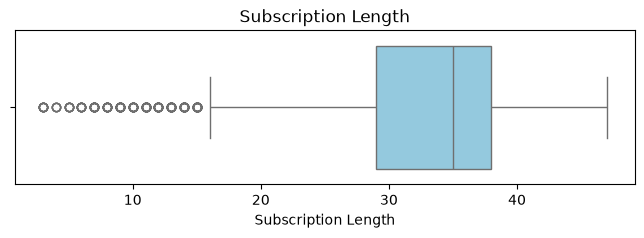

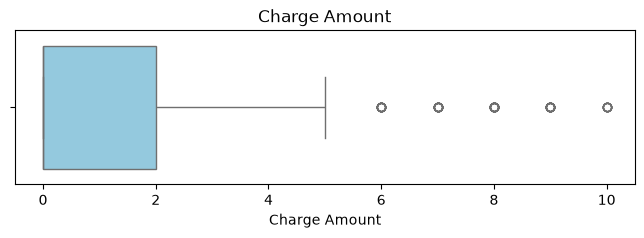

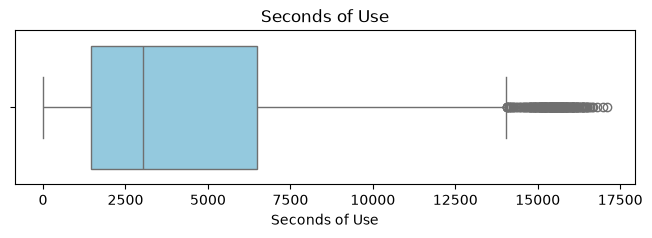

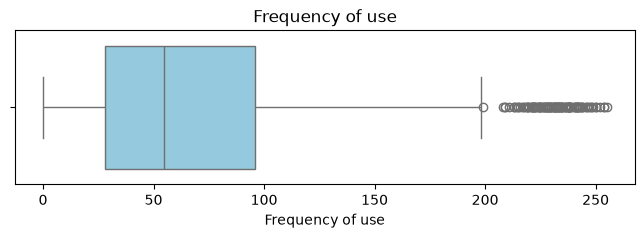

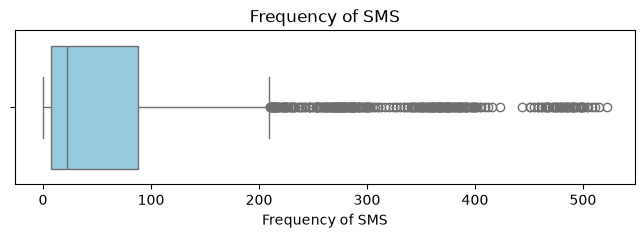

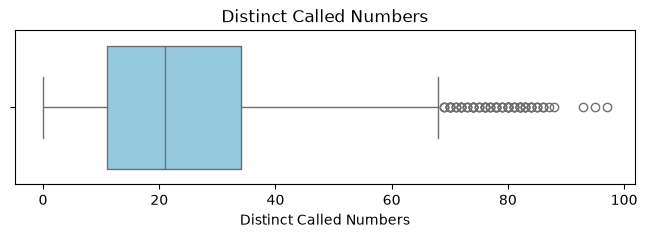

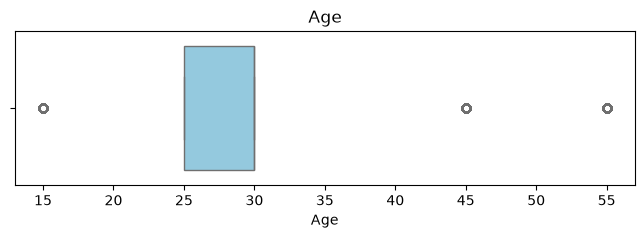

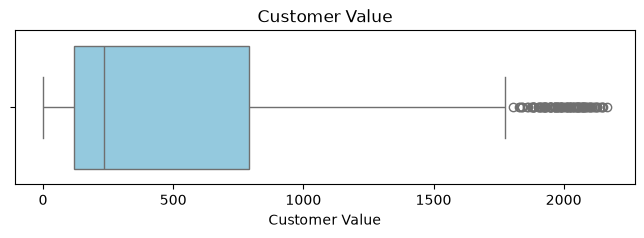

In [39]:
for col in numerical_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col],
        color="skyblue"
    )

    plt.title(col)

    plt.show()

### Count Outliers

In [40]:
outlier_summary = []

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    outlier_summary.append({

        "Feature": col,

        "Outliers": len(outliers),

        "Percentage":
            round(
                len(outliers)/len(df)*100,
                2
            )

    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Feature,Outliers,Percentage
0,Subscription Length,208,7.30
1,Charge Amount,62,2.18
2,Seconds of Use,189,6.63
3,Frequency of use,118,4.14
4,Frequency of SMS,333,11.68
5,Distinct Called Numbers,82,2.88
6,Age,633,22.21
7,Customer Value,104,3.65


## Observation

Outliers were identified in several numerical variables.

After reviewing the dataset and business context, these values appear to represent genuine customer behavior (for example, premium customers with high usage) rather than data entry errors.

Therefore, no outliers were removed.

### Section 8 — Distribution Check

In [41]:
skewness = df[numerical_cols].skew()

skewness.sort_values()

Subscription Length       -1.252843
Distinct Called Numbers    1.039277
Frequency of use           1.145862
Age                        1.223952
Seconds of Use             1.314737
Customer Value             1.422214
Frequency of SMS           1.971020
Charge Amount              2.533804
dtype: float64

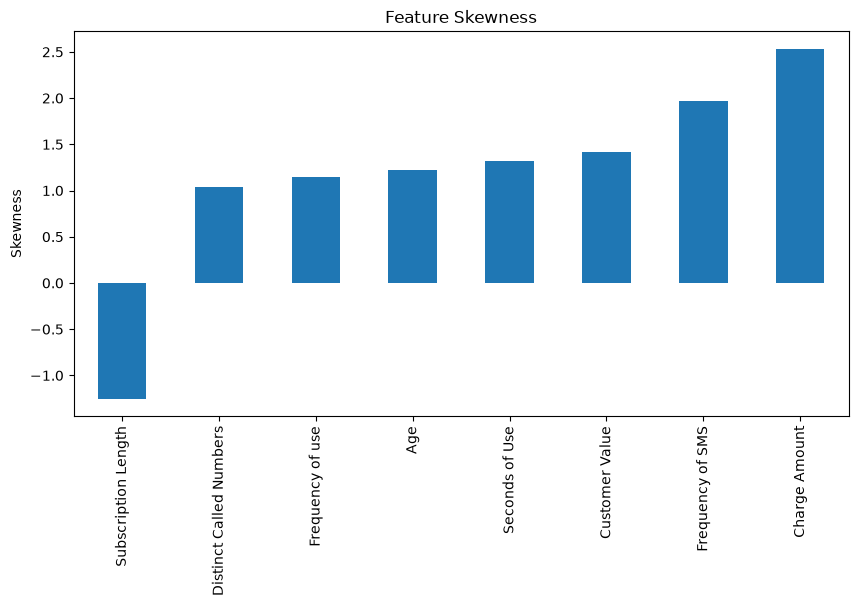

In [42]:
plt.figure(figsize=(10,5))

skewness.sort_values().plot(
    kind="bar"
)

plt.title("Feature Skewness")

plt.ylabel("Skewness")

plt.show()

## Observation

Several variables exhibit moderate positive skewness, particularly Customer Value.

However, tree-based machine learning algorithms are generally robust to skewed feature distributions, so no transformation was applied.

### Section 9 — Feature Engineering

The engineered variables summarize customer behavior into higher-level business metrics. These features help machine learning models identify patterns that may not be evident from the original variables alone, such as engagement intensity, average calling behavior, and monthly customer value.

In [43]:
print(df.columns.tolist())

['Call Failure', 'Complains', 'Subscription Length', 'Charge Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value', 'Churn']


In [44]:
# Feature 1: Customer Engagement

df["Customer_Engagement"] = (
    df["Frequency of use"] +
    df["Frequency of SMS"] +
    df["Distinct Called Numbers"]
)

##### Business Meaning

A customer who:

makes many calls,
sends many SMS,
contacts many unique numbers,

is generally more engaged with the telecom service.

In [45]:
# Feature 2: Average Call Duration

df["Average_Call_Duration"] = (
    df["Seconds of Use"] /
    (df["Frequency of use"] + 1)
)

##### Business Meaning

This estimates the average duration of each call.

In [46]:
# Feature 3: Revenue Per Month

df["Revenue_Per_Month"] = (
    df["Customer Value"] /
    (df["Subscription Length"] + 1)
)

##### Business Meaning
Instead of total customer value, this measures how much revenue the customer generates per month.

In [47]:
df[[
    "Customer_Engagement",
    "Average_Call_Duration",
    "Revenue_Per_Month"
]].head()

,Customer_Engagement,Average_Call_Duration,Revenue_Per_Month
0,93,60.694444,5.067692
1,16,53.000000,1.150875
2,443,40.213115,40.434737
3,102,62.656716,6.154359
4,93,40.559322,3.738590


In [48]:
print(df.shape)

(2850, 17)


In [50]:
# Describe New Features

df[[
    "Customer_Engagement",
    "Average_Call_Duration",
    "Revenue_Per_Month"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Engagement,2850.0,168.145263,137.940424,0.0,63.250000,122.000000,262.000000,615.00000
Average_Call_Duration,2850.0,60.111661,29.476044,0.0,43.571429,58.120660,71.717152,325.00000
Revenue_Per_Month,2850.0,15.944959,21.559964,0.0,3.688426,7.047643,23.467443,271.27125


## Observation

Three business-oriented features were engineered from the original customer data.

- **Customer Engagement** captures the overall interaction level of a customer by combining call frequency, SMS frequency, and the number of distinct contacts.
- **Average Call Duration** estimates the average duration of each call, providing insights into calling behavior.
- **Revenue Per Month** measures the average monthly revenue generated by each customer based on customer value and subscription length.

These engineered features provide richer behavioral information than the original variables and are expected to improve churn prediction performance.

In [51]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/churn_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [52]:
print("="*60)
print("DATA PREPROCESSING SUMMARY")
print("="*60)

print(f"Dataset Shape : {df.shape}")
print(f"Missing Values : {df.isnull().sum().sum()}")
print(f"Duplicate Rows : {df.duplicated().sum()}")

print("\nNew Features Created:")
print("• Customer_Engagement")
print("• Average_Call_Duration")
print("• Revenue_Per_Month")

print("\nDataset is ready for Feature Selection.")

DATA PREPROCESSING SUMMARY
Dataset Shape : (2850, 17)
Missing Values : 0
Duplicate Rows : 0

New Features Created:
• Customer_Engagement
• Average_Call_Duration
• Revenue_Per_Month

Dataset is ready for Feature Selection.


### Output

The processed dataset has been saved as:

data/processed/churn_processed.csv

This dataset will be used in Notebook 05 for Feature Selection.